In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, silhouette_score
from sklearn.decomposition import PCA
from scipy.stats import chi2
from sklearn.mixture import GaussianMixture

# Classificador

In [2]:
def matriz_conf(y_true, y_pred, labels):
    total_labels = labels
    print(total_labels)
    cm = np.zeros((len(total_labels),len(total_labels)), dtype=int)
    for i in range(len(y_true)):
        cm[y_true[i]][y_pred[i]] += 1
    
    cm = pd.DataFrame(cm, columns=total_labels, index=total_labels)

    cm_transp = pd.DataFrame(np.transpose(cm.to_numpy()), columns=total_labels, index=total_labels)

    for c in cm_transp.columns:
        cm_transp[c] = cm_transp[c]/cm_transp[c].sum()

    cm_porcento = pd.DataFrame(np.transpose(cm_transp.to_numpy()), columns=total_labels, index=total_labels)

    return cm, cm_porcento

def acc(cm, hidden_classes):
    cm_transp = pd.DataFrame(np.transpose(cm.dropna().to_numpy()), columns=cm.columns, index=cm.columns)
    acc = 0
    total = 0
    for c in cm_transp.columns:
        if c not in hidden_classes:
            acc += cm_transp[c][c]
        else:
            acc += cm_transp[c][-1]
        total += cm_transp[c].sum()
    return acc/total

# Calcula CM para todos

In [3]:
filenames = [0,2,3,4,5]

labels_str = ['DDoS', 'Benign', 'DoS', 'BruteForce', 'Bot', 'Web']

filenames

# pd.set_option('future.no_silent_downcasting', True)

[0, 2, 3, 4, 5]

0


Label
1    514148
2    329224
3    243806
4    183163
5       596
Name: count, dtype: int64

Tipo: 1 = Benign
Melhor modelo: n_componentes: 10 covariance_type: full


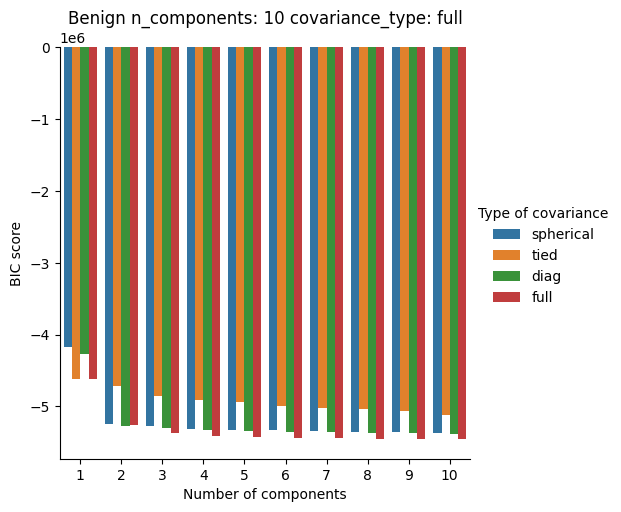

Tipo: 2 = DoS
Melhor modelo: n_componentes: 10 covariance_type: full


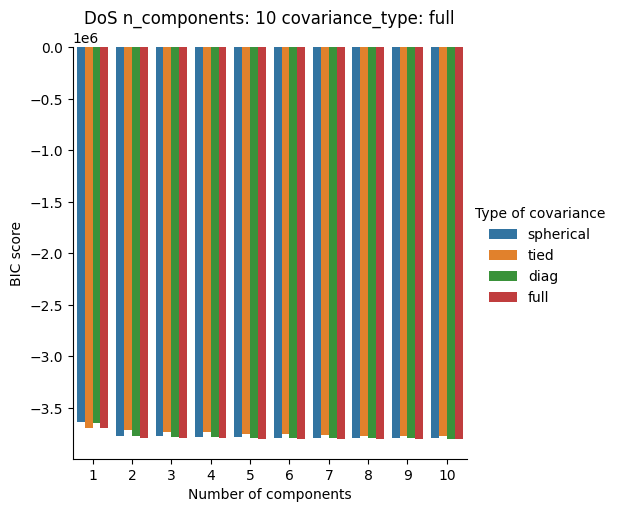

Tipo: 3 = BruteForce
Melhor modelo: n_componentes: 6 covariance_type: full


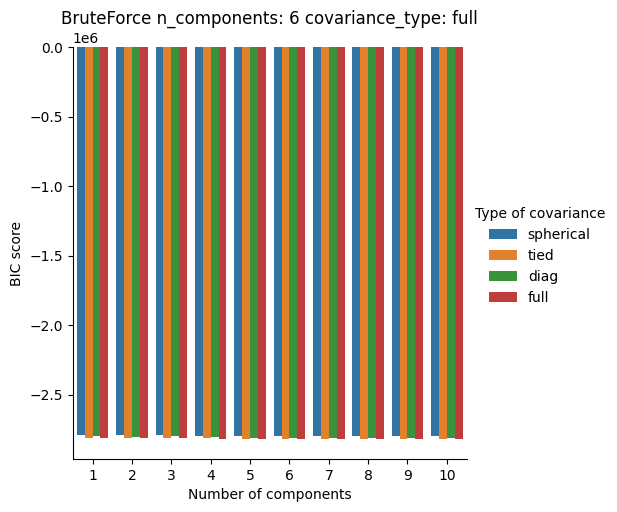

Tipo: 4 = Bot
Melhor modelo: n_componentes: 7 covariance_type: full


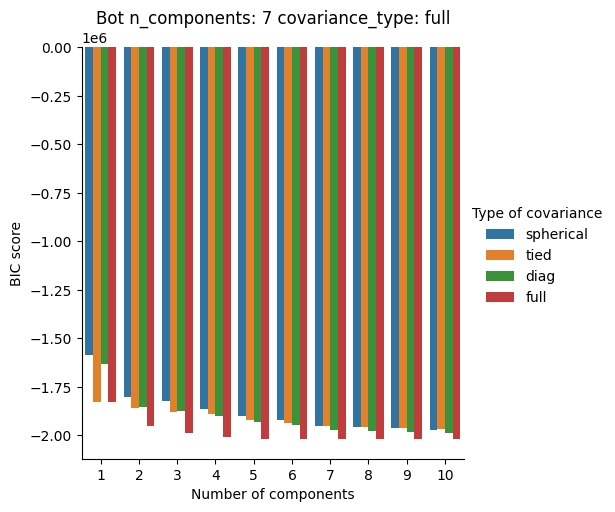

Tipo: 5 = Web
Melhor modelo: n_componentes: 10 covariance_type: spherical


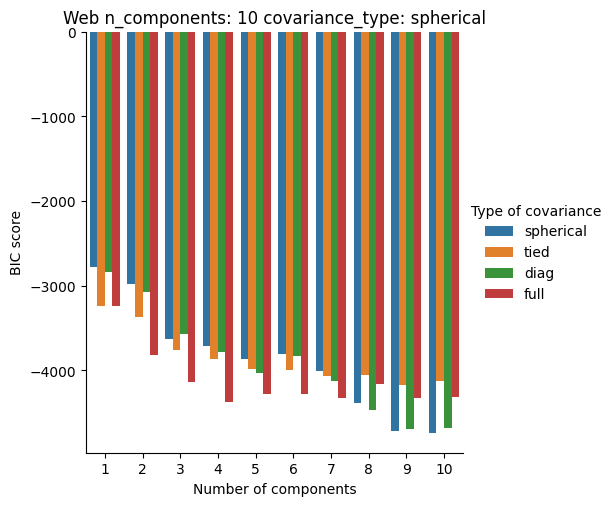

,0,1,2,3,4,5
0,NaN,16.520096,-2.784823,-1185.295700,4.469208,9.614722
1,NaN,8.514722,29.470900,14.987422,-143.675860,4.623015
2,NaN,27.521325,-10.674455,-994.443032,13.453042,7.633727
3,NaN,3.946588,-9.670457,28.975662,-928.317680,4.449424
4,NaN,28.023526,-10.200547,-941.274338,13.316378,7.496652
...,...,...,...,...,...,...
519951,NaN,26.911258,-9.193787,-1001.644675,13.305715,7.637875
519952,NaN,12.658837,-132.370426,-604.212631,28.957094,15.018810
519953,NaN,16.205631,-8.767208,-812.392067,12.329182,6.410139
519954,NaN,27.670379,-9.862460,-954.733605,12.129060,7.743414


,0,1,2,3,4,5
0,NaN,16.346744,-8.705526,-813.268548,12.327792,6.437350
1,NaN,16.503717,-3.029921,-1198.717214,4.383016,9.617762
2,NaN,28.062475,-9.586012,-960.986660,13.500036,7.603603
3,NaN,27.437675,-10.433823,-1008.867732,13.211388,7.616103
4,NaN,5.039850,-0.099176,-695.146696,-9.919468,8.395029
...,...,...,...,...,...,...
649942,NaN,28.055389,-10.427383,-948.197665,13.267383,7.501502
649943,NaN,3.656750,-6.120778,-767.144999,-12.669993,8.416955
649944,NaN,3.960976,-5.403847,-761.702718,-12.128975,8.427488
649945,NaN,4.105838,-9.199151,28.877573,-915.378165,4.481778


2


Label
0    808919
1    514148
3    243806
4    183163
5       596
Name: count, dtype: int64

Tipo: 0 = DDoS
Melhor modelo: n_componentes: 10 covariance_type: full


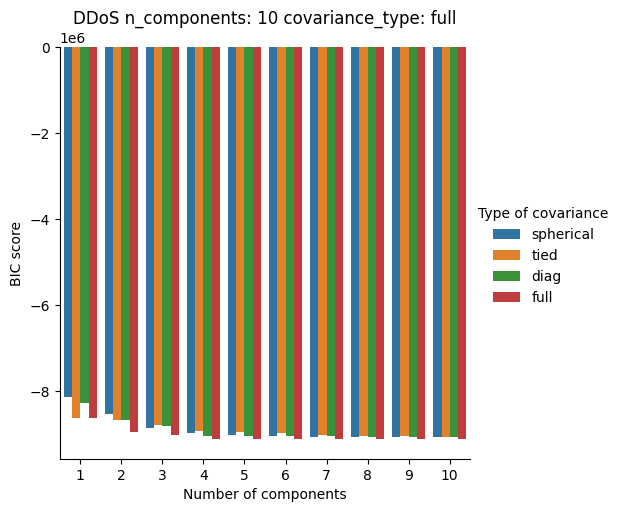

Tipo: 1 = Benign
Melhor modelo: n_componentes: 10 covariance_type: full


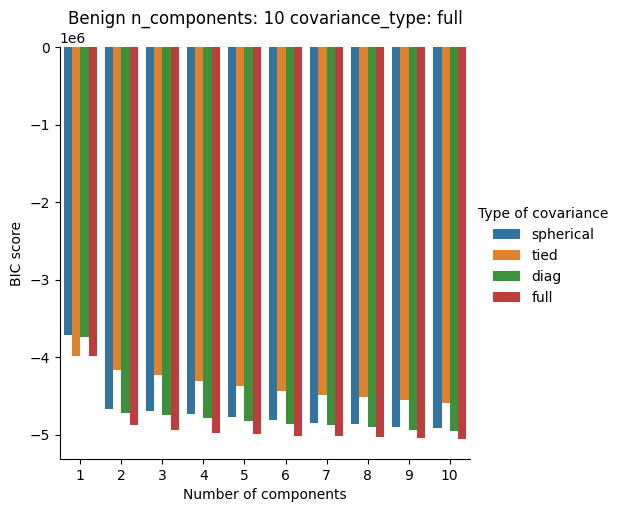

Tipo: 3 = BruteForce
Melhor modelo: n_componentes: 9 covariance_type: full


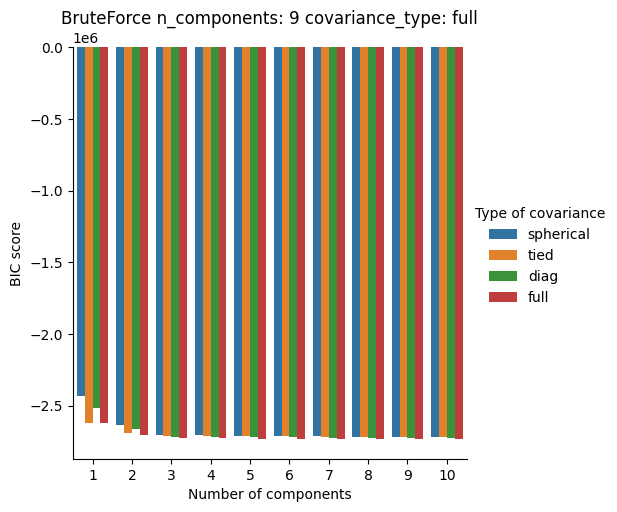

Tipo: 4 = Bot
Melhor modelo: n_componentes: 10 covariance_type: full


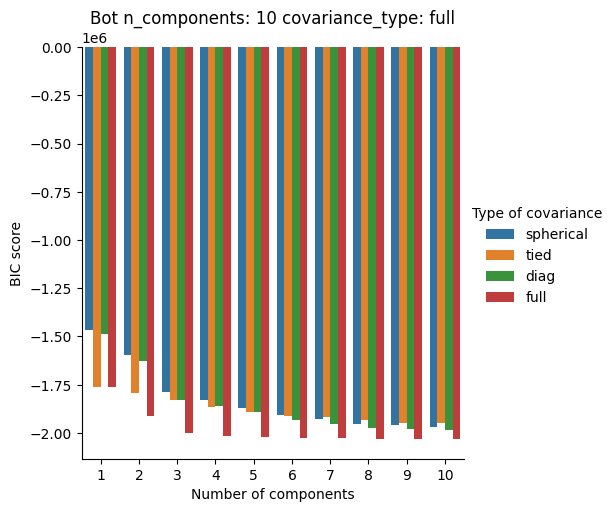

Tipo: 5 = Web
Melhor modelo: n_componentes: 5 covariance_type: full


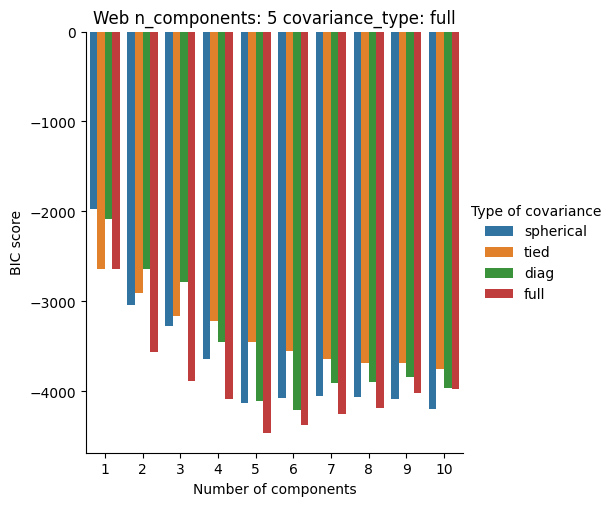

,0,1,2,3,4,5
0,28.149907,14.072099,NaN,-645.815541,4.579571,-0.583874
1,-38.810307,13.769314,NaN,-62.924040,-6.038186,11.240763
2,-5.219640,25.438580,NaN,-43.609817,15.221128,11.861619
3,-96.666595,4.589083,NaN,27.379663,-149.455439,-1.550451
4,-5.894110,26.482620,NaN,-52.721269,15.322668,11.327050
...,...,...,...,...,...,...
519951,-12.202089,26.181369,NaN,-44.333946,14.616950,12.645830
519952,-97.634234,12.409622,NaN,-1507.434811,29.138036,19.485636
519953,28.809047,15.684931,NaN,-691.383438,5.463733,-0.906697
519954,-10.124259,24.764706,NaN,-63.961946,11.008422,12.509117


,0,1,2,3,4,5
0,28.770030,16.431512,NaN,-685.098247,5.495810,-0.771587
1,28.142201,14.004827,NaN,-649.148332,4.569376,-0.633261
2,-24.949710,22.196322,NaN,-65.686546,16.035181,12.270577
3,-3.891895,19.985926,NaN,-41.498004,8.720079,12.409637
4,27.823397,16.149856,NaN,-666.044753,4.497572,-0.797369
...,...,...,...,...,...,...
649942,-11.639877,26.418081,NaN,-54.714675,14.525854,11.246807
649943,27.624978,16.451824,NaN,-665.616254,4.569432,-0.819163
649944,27.727097,16.257663,NaN,-667.585390,4.530528,-0.871987
649945,-84.896001,4.270937,NaN,28.021005,-149.490255,-2.894802


3


Label
0    808919
1    514148
2    329224
4    183163
5       596
Name: count, dtype: int64

Tipo: 0 = DDoS
Melhor modelo: n_componentes: 10 covariance_type: full


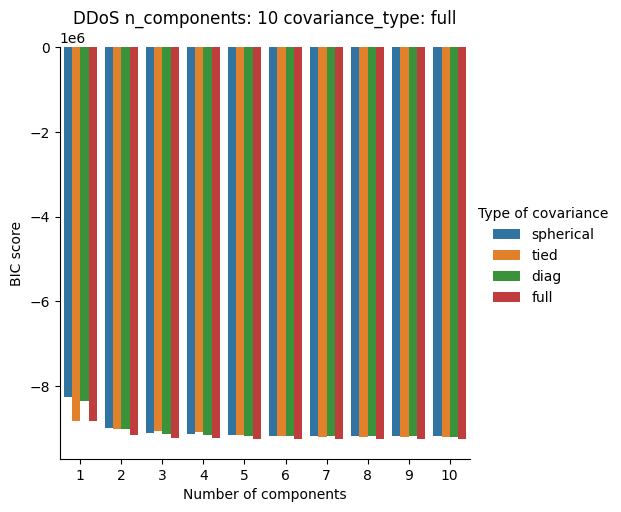

Tipo: 1 = Benign
Melhor modelo: n_componentes: 10 covariance_type: full


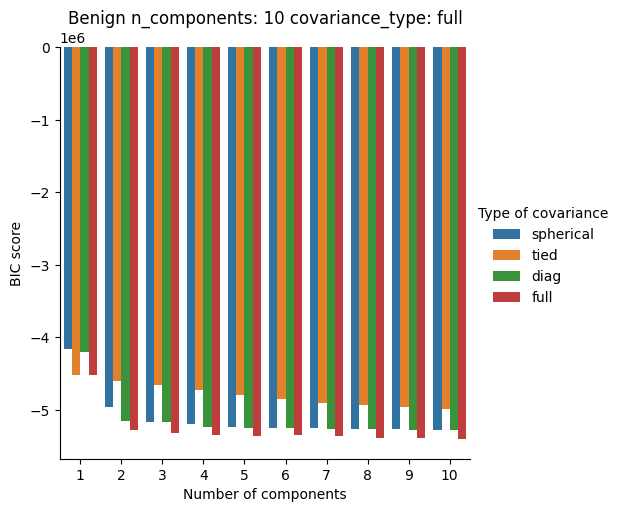

Tipo: 2 = DoS
Melhor modelo: n_componentes: 9 covariance_type: full


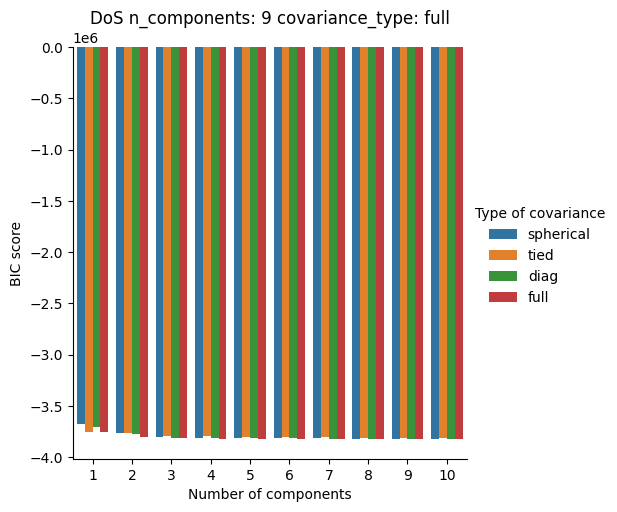

Tipo: 4 = Bot
Melhor modelo: n_componentes: 10 covariance_type: full


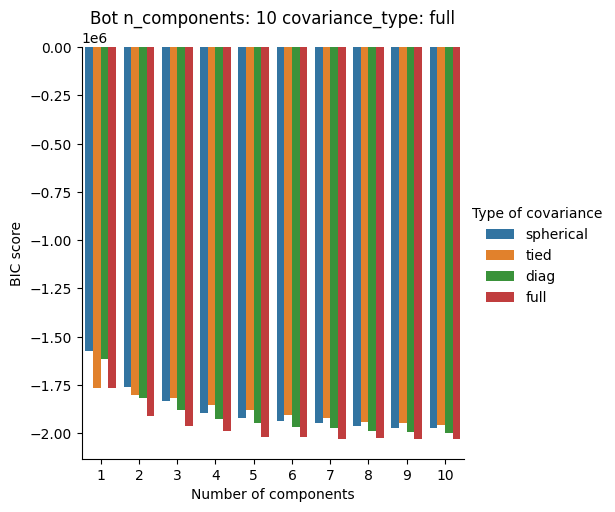

Tipo: 5 = Web
Melhor modelo: n_componentes: 5 covariance_type: full


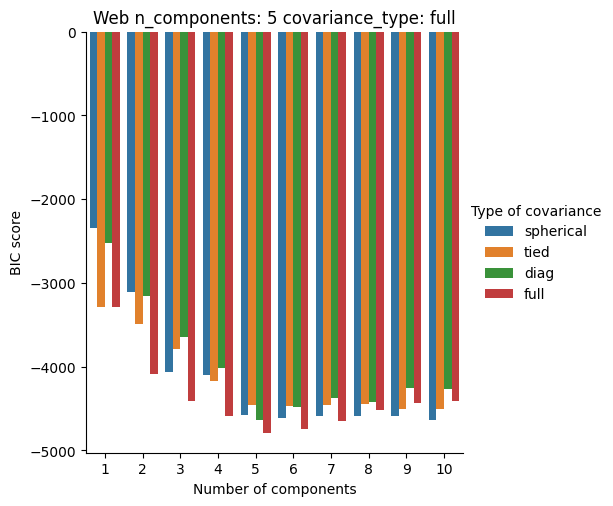

,0,1,2,3,4,5
0,28.758744,9.447729,-221.756480,NaN,7.117979,4.664633
1,-15.441893,11.458085,29.544152,NaN,-159.849411,1.210247
2,3.726011,27.041707,2.097100,NaN,10.180055,10.262735
3,-12.236378,13.121081,17.737777,NaN,-115.921248,-0.458897
4,8.464931,27.927546,-0.371388,NaN,13.165591,13.732678
...,...,...,...,...,...,...
519951,6.573110,28.110307,1.000660,NaN,13.407102,13.134150
519952,-19.408842,6.386388,-145.043190,NaN,28.939005,19.225891
519953,29.201132,13.395484,-205.729885,NaN,7.973278,6.499930
519954,8.261117,27.451818,-1.491565,NaN,14.491946,14.552749


,0,1,2,3,4,5
0,29.178637,13.323202,-206.650928,NaN,8.030759,6.610921
1,28.559328,9.330701,-225.154178,NaN,7.156740,5.036777
2,6.913666,27.394556,-0.335963,NaN,13.877090,13.290081
3,5.476539,24.860098,1.262459,NaN,12.853301,12.644331
4,29.059445,12.962351,-210.714024,NaN,7.967031,6.478500
...,...,...,...,...,...,...
649942,8.437076,27.935210,-0.368143,NaN,13.301091,13.840974
649943,29.016059,11.289349,-213.221825,NaN,7.873783,5.884097
649944,28.963305,11.396514,-214.540691,NaN,7.941267,6.275513
649945,-5.355249,12.859106,16.123183,NaN,-114.321003,5.582848


4


Label
0    808919
1    514148
2    329224
3    243806
5       596
Name: count, dtype: int64

Tipo: 0 = DDoS
Melhor modelo: n_componentes: 10 covariance_type: full


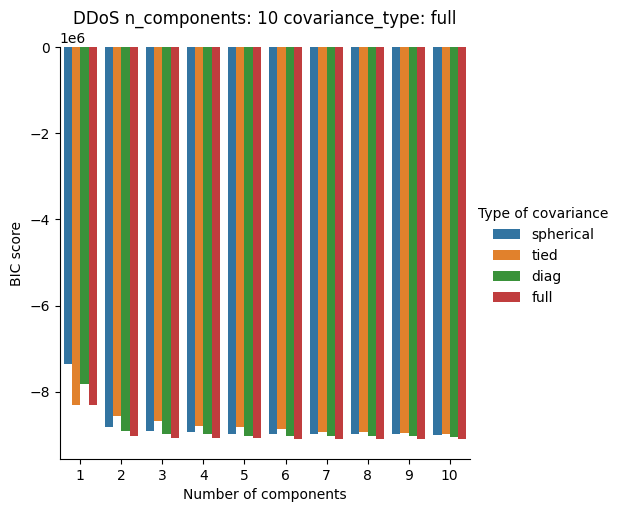

Tipo: 1 = Benign
Melhor modelo: n_componentes: 10 covariance_type: full


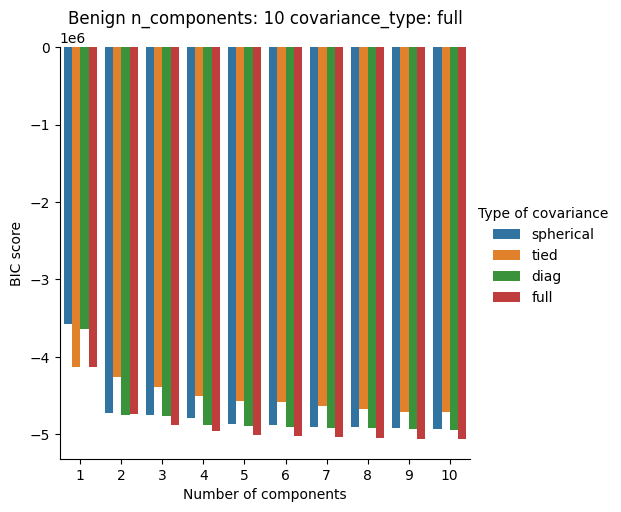

Tipo: 2 = DoS
Melhor modelo: n_componentes: 10 covariance_type: full


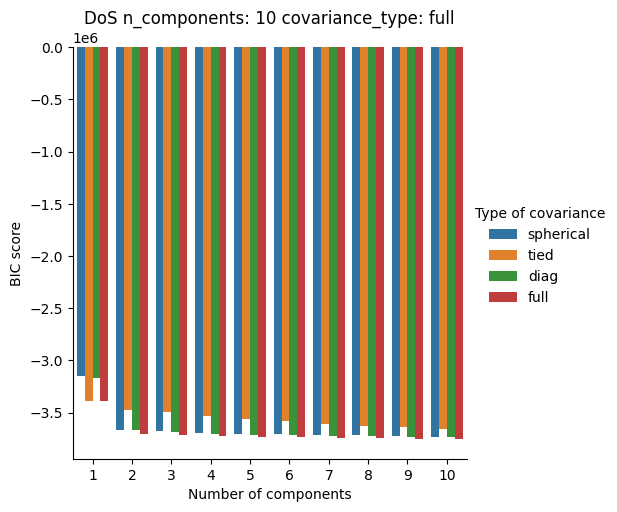

Tipo: 3 = BruteForce
Melhor modelo: n_componentes: 7 covariance_type: full


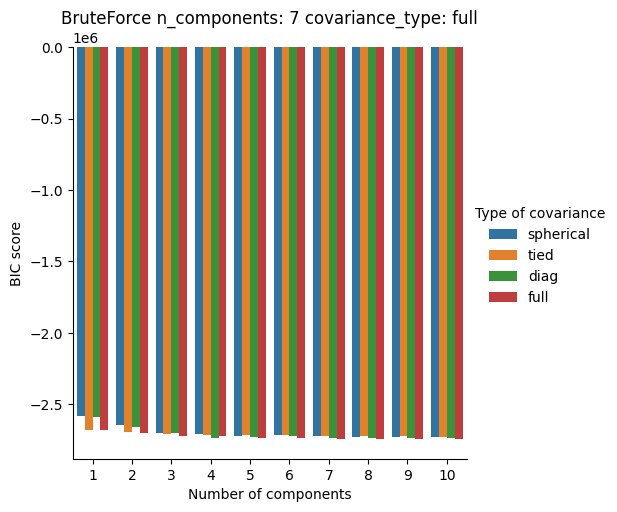

Tipo: 5 = Web
Melhor modelo: n_componentes: 10 covariance_type: spherical


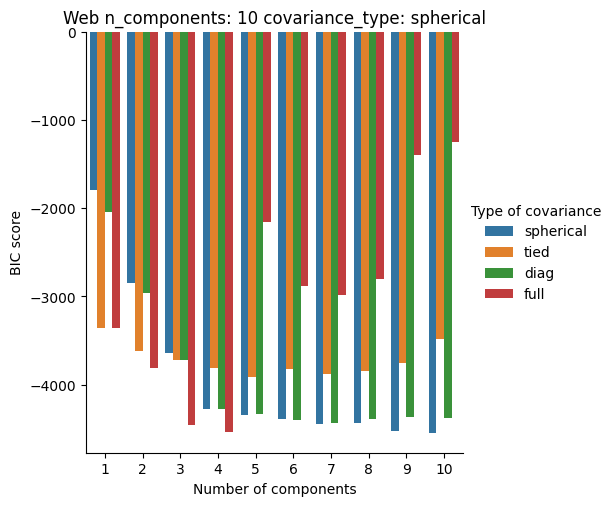

,0,1,2,3,4,5
0,28.401247,11.013818,-121.708169,-2866.150299,NaN,2.691192
1,-1831.920619,4.632632,29.469829,-34.121104,NaN,-4.864128
2,-24.925165,26.215827,-37.854587,-602.484088,NaN,4.879726
3,-4610.107195,-19.870404,-116.554466,27.528603,NaN,-0.624464
4,-16.248656,27.067187,-35.023062,-621.304357,NaN,4.855858
...,...,...,...,...,...,...
519951,-19.921595,24.811353,-38.886364,-621.614513,NaN,4.945873
519952,6.937014,20.291607,-22.107897,-723.611077,NaN,4.816452
519953,28.671334,9.181066,-131.234963,-2887.494222,NaN,2.443179
519954,-38.212226,25.576070,-35.535203,-579.967118,NaN,4.785157


,0,1,2,3,4,5
0,28.651146,8.870750,-131.843252,-2896.555171,NaN,2.410072
1,28.429995,11.021363,-122.030280,-2868.294552,NaN,2.677336
2,8.159360,21.610832,-23.105887,-684.775462,NaN,4.931977
3,-11.875602,20.411219,-44.796525,-734.679566,NaN,4.598979
4,28.065285,9.226145,-137.184086,-2824.777649,NaN,2.660620
...,...,...,...,...,...,...
649942,-17.108221,27.055411,-35.196053,-619.819330,NaN,4.846000
649943,27.383683,9.452080,-138.493831,-2802.453124,NaN,2.714315
649944,27.556666,9.227946,-138.432345,-2822.682722,NaN,2.712013
649945,-4780.665663,-20.298576,-113.963562,28.367564,NaN,-0.848990


5


Label
0    808919
1    514148
2    329224
3    243806
4    183163
Name: count, dtype: int64

Tipo: 0 = DDoS
Melhor modelo: n_componentes: 6 covariance_type: full


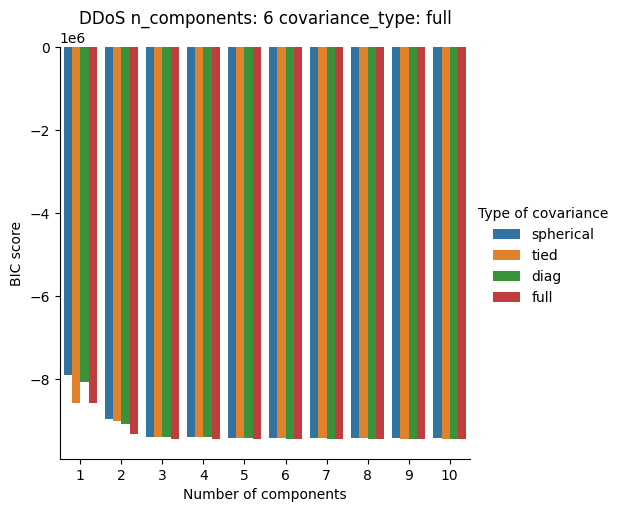

Tipo: 1 = Benign
Melhor modelo: n_componentes: 9 covariance_type: full


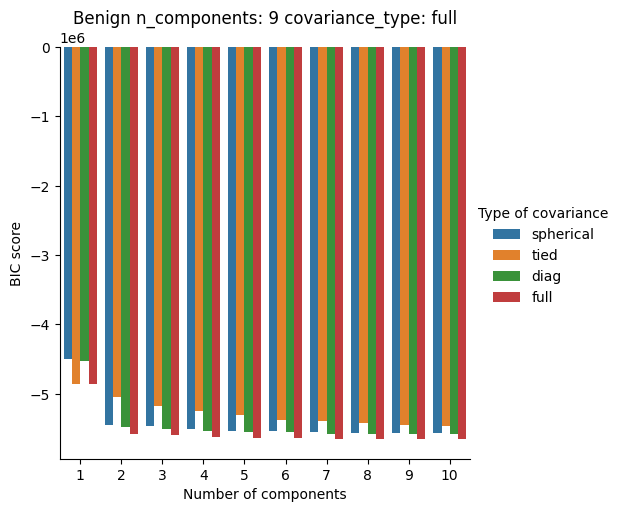

Tipo: 2 = DoS
Melhor modelo: n_componentes: 6 covariance_type: full


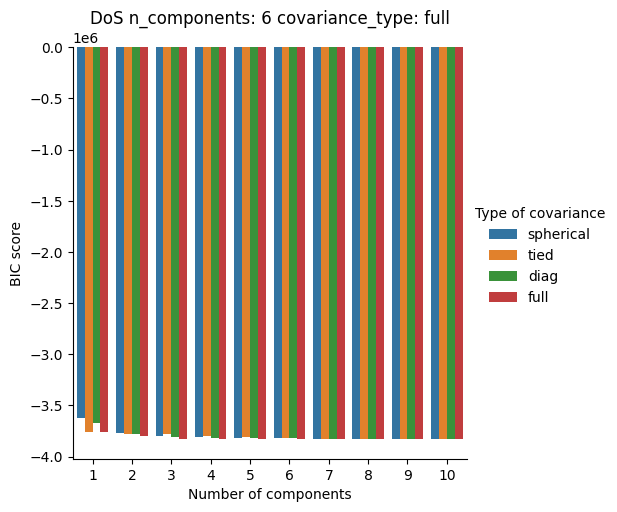

Tipo: 3 = BruteForce
Melhor modelo: n_componentes: 8 covariance_type: full


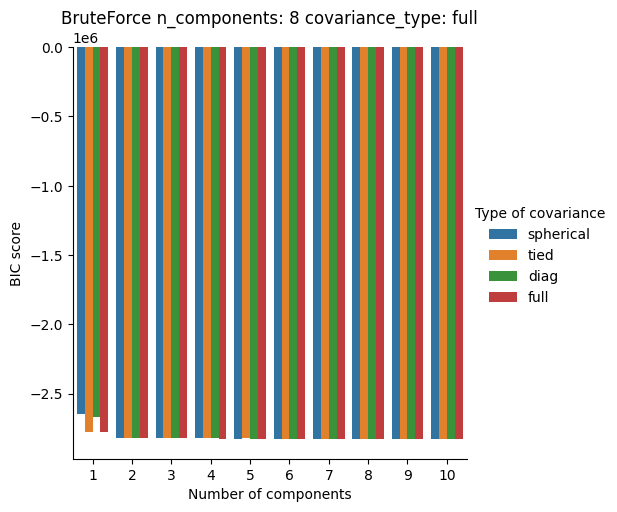

Tipo: 4 = Bot
Melhor modelo: n_componentes: 8 covariance_type: full


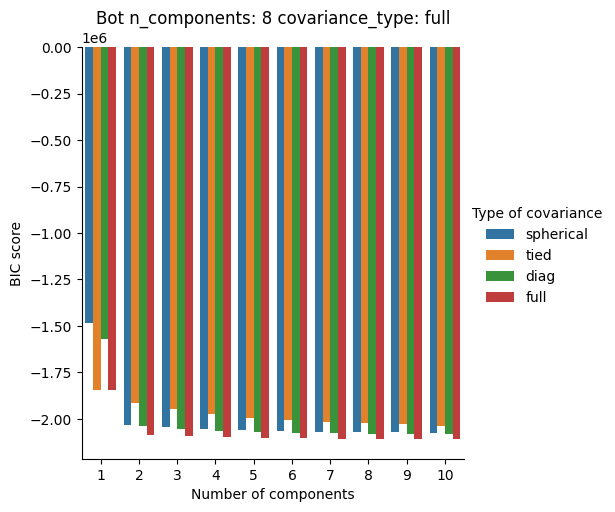

,0,1,2,3,4,5
0,29.470547,14.528546,-354.438647,-2424.251814,9.345381,NaN
1,-661.020992,15.192631,29.532954,17.539738,-208.365458,NaN
2,15.439939,27.912109,-113.041538,-413.412718,16.749246,NaN
3,-3219.631997,11.386146,-38.273651,29.120291,-2778.823571,NaN
4,13.677431,28.248476,-122.009569,-439.424312,16.775140,NaN
...,...,...,...,...,...,...
519951,16.503966,28.277917,-113.351663,-419.186747,17.547488,NaN
519952,-176.896294,13.986341,-2753.629976,-3819.468236,29.505684,NaN
519953,29.414451,13.672963,-351.875890,-2400.195441,7.809197,NaN
519954,11.116976,27.765213,-109.299319,-400.499310,15.353416,NaN


,0,1,2,3,4,5
0,29.408013,13.691293,-351.976575,-2398.935715,7.793314,NaN
1,29.426748,14.498617,-354.355537,-2426.162683,9.403230,NaN
2,15.568207,28.372642,-117.086038,-424.062790,17.351700,NaN
3,10.601923,22.874194,-111.352362,-371.169699,10.118498,NaN
4,29.243087,14.348204,-352.271512,-2388.948611,8.519896,NaN
...,...,...,...,...,...,...
649942,13.898478,28.406638,-121.025590,-436.868962,16.938218,NaN
649943,29.139881,14.753147,-352.747321,-2392.177043,8.937484,NaN
649944,29.182352,14.700949,-351.517714,-2387.401936,8.966803,NaN
649945,-3235.178692,11.310560,-44.337190,29.232847,-2785.611557,NaN


In [4]:
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import GridSearchCV
import seaborn as sns
import os

def gmm_bic_score(estimator, X):
    """Callable to pass to GridSearchCV that will use the BIC score."""
    # Make it negative since GridSearchCV expects a score to maximize
    return -estimator.bic(X)


param_grid = {
    "n_components": range(1, 11),
    "covariance_type": ["spherical", "tied", "diag", "full"],
    "random_state": [123],
}

exp_train = []
exp_val = []
exp_test = []
y_true_all_exp_train = []
y_true_all_exp_val = []
y_true_all_exp_test = []
for z in range(len(filenames)):
    
    train_encoded_df = pd.read_csv(f'train_encoded_CADE_cod_joined_attacks_pick_class_squared_normalized_{filenames[z]}_hidden.csv')
    val_encoded_df = pd.read_csv(f'val_encoded_CADE_cod_joined_attacks_pick_class_squared_normalized_{filenames[z]}_hidden.csv')
    test_encoded_df = pd.read_csv(f'test_encoded_CADE_cod_joined_attacks_pick_class_squared_normalized_{filenames[z]}_hidden.csv')
    y_true_all_exp_train.append(train_encoded_df['Label'].values.tolist())
    y_true_all_exp_val.append(val_encoded_df['Label'].values.tolist())
    y_true_all_exp_test.append(test_encoded_df['Label'].values.tolist())
    print(filenames[z])
    hidden_classes = [filenames[z]] # Classes ocultas do treinamento
    for i in range(len(labels_str)):
        train_encoded_df['Label'] = train_encoded_df['Label'].replace(labels_str[i],i)
        val_encoded_df['Label'] = val_encoded_df['Label'].replace(labels_str[i],i)
        test_encoded_df['Label'] = test_encoded_df['Label'].replace(labels_str[i],i)

    display(train_encoded_df['Label'].value_counts())
        
    
        
    gmms = []
    for i in range(len(labels_str)):
        if i not in hidden_classes:
            print(f'Tipo: {i} = {labels_str[i]}')
            grid_search = GridSearchCV(
                GaussianMixture(), param_grid=param_grid, scoring=gmm_bic_score
            )
            grid_search.fit(train_encoded_df[train_encoded_df['Label'] == i].drop(columns=['Label']).to_numpy())
            print(f"Melhor modelo: n_componentes: {grid_search.best_params_['n_components']} covariance_type: {grid_search.best_params_['covariance_type']}")
            gmms.append(grid_search.best_estimator_)
            df = pd.DataFrame(grid_search.cv_results_)[
                ["param_n_components", "param_covariance_type", "mean_test_score"]
            ]
            df["mean_test_score"] = -df["mean_test_score"]
            df = df.rename(
                columns={
                    "param_n_components": "Number of components",
                    "param_covariance_type": "Type of covariance",
                    "mean_test_score": "BIC score",
                }
            )
            df.sort_values(by="BIC score").head()
            sns.catplot(
                data=df,
                kind="bar",
                x="Number of components",
                y="BIC score",
                hue="Type of covariance",
                
            ).set(title = f"{labels_str[i]} n_components: {grid_search.best_params_['n_components']} covariance_type: {grid_search.best_params_['covariance_type']}")
            plt.show()
            # plt.savefig(f'class_{i}_train_{filenames[z]}_GMM_BIC_1_10_scores.png')
        else:
            gmms.append(None)
    
    # scores = []
    # for i, row in train_encoded_df.drop(columns=['Label']).iterrows():
    #     max_dist = -np.inf
    #     pred = -1
    #     scores.append([])
    #     for j in range(len(labels_str)):
    #         if j not in hidden_classes:
    #             inside = False
    #             max = -np.inf
    #             # score = np.exp(gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0])*priors[j]
    #             score = gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0]
    #             scores[i].append(score)
    #         else:
    #             scores[i].append(np.nan)
    
    
    # display(pd.DataFrame(scores))
    # exp_train.append(scores)
    #pd.DataFrame(scores).to_csv(f'train_{filenames[z]}_GMM_BIC_1_10_scores.csv',index=False)

    scores = []
    for i, row in val_encoded_df.drop(columns=['Label']).iterrows():
        max_dist = -np.inf
        pred = -1
        scores.append([])
        for j in range(len(labels_str)):
            if j not in hidden_classes:
                inside = False
                max = -np.inf
                # score = np.exp(gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0])*priors[j]
                score = gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0]
                scores[i].append(score)
            else:
                scores[i].append(np.nan)
    
    
    display(pd.DataFrame(scores))
    exp_val.append(scores)
    scores_df = pd.DataFrame(scores)
    scores_df['Label'] = val_encoded_df["Label"].values
    scores_df.to_csv(f'val_{filenames[z]}_GMM_BIC_1_10_scores.csv', index=False)

    scores = []
    for i, row in test_encoded_df.drop(columns=['Label']).iterrows():
        max_dist = -np.inf
        pred = -1
        scores.append([])
        for j in range(len(labels_str)):
            if j not in hidden_classes:
                inside = False
                max = -np.inf
                # score = np.exp(gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0])*priors[j]
                score = gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0]
                scores[i].append(score)
            else:
                scores[i].append(np.nan)
    
    
    display(pd.DataFrame(scores))
    exp_test.append(scores)
    scores_df = pd.DataFrame(scores)
    scores_df['Label'] = test_encoded_df["Label"].values
    scores_df.to_csv(f'test_{filenames[z]}_GMM_BIC_1_10_scores.csv', index=False)